# 🌲 Random Forest vs XGBoost — Model Comparison

**Workflow:**
- `train_data.csv` → fit models + StratifiedKFold CV
- `val_data.csv` → hyperparameter validation / early monitoring
- `test_data.csv` → final held-out evaluation (touched once at the end)

**Target:** `label` (binary: 0 or 1)

---

## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
from sklearn.pipeline import Pipeline

import xgboost as xgb

RANDOM_STATE = 42
N_SPLITS     = 5

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All imports successful ✅')

All imports successful ✅


## 2. Load Data Splits

In [2]:
train_df = pd.read_csv('../data/train_data.csv')
val_df   = pd.read_csv('../data/val_data.csv')
test_df  = pd.read_csv('../data/test_data.csv')

print(f'Train samples : {len(train_df):,}')
print(f'Val samples   : {len(val_df):,}')
print(f'Test samples  : {len(test_df):,}')
print(f'\nColumns: {list(train_df.columns)}')

Train samples : 564
Val samples   : 121
Test samples  : 121

Columns: ['num_rows', 'num_columns', 'num_numeric_columns', 'num_string_columns', 'null_ratio_mean', 'null_ratio_max', 'null_ratio_std', 'num_high_null_columns', 'avg_unique_ratio', 'min_unique_ratio', 'num_constant_columns', 'num_mixed_type_columns', 'avg_string_length_variance', 'max_string_length_variance', 'avg_skewness', 'avg_kurtosis', 'empty_row_ratio', 'label', 'source', 'timestamp']


## 3. EDA — Training Set

In [3]:
print('=== Training Set — Descriptive Statistics ===')
train_df.describe().T

=== Training Set — Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
num_rows,564.0,72283.381206,48252.670070,115.000000,1453.750000,100000.000000,100000.000000,124900.000000
num_columns,564.0,10.753546,7.666071,1.000000,7.000000,11.000000,11.000000,117.000000
num_numeric_columns,564.0,4.287234,4.414466,0.000000,2.000000,4.000000,5.000000,54.000000
num_string_columns,564.0,6.423759,4.744581,0.000000,2.000000,7.000000,9.000000,63.000000
null_ratio_mean,564.0,0.228046,0.213845,0.000000,0.000000,0.136973,0.454545,0.762743
null_ratio_max,564.0,0.516423,0.483599,0.000000,0.000000,0.615700,1.000000,1.000000
null_ratio_std,564.0,0.230519,0.230506,0.000000,0.000000,0.172332,0.474883,0.497930
num_high_null_columns,564.0,2.572695,5.664388,0.000000,0.000000,1.000000,5.000000,89.000000
avg_unique_ratio,564.0,0.382283,0.222056,0.042413,0.229283,0.273602,0.576546,0.989220
min_unique_ratio,564.0,0.014056,0.104322,0.000008,0.000010,0.000010,0.000794,0.989220


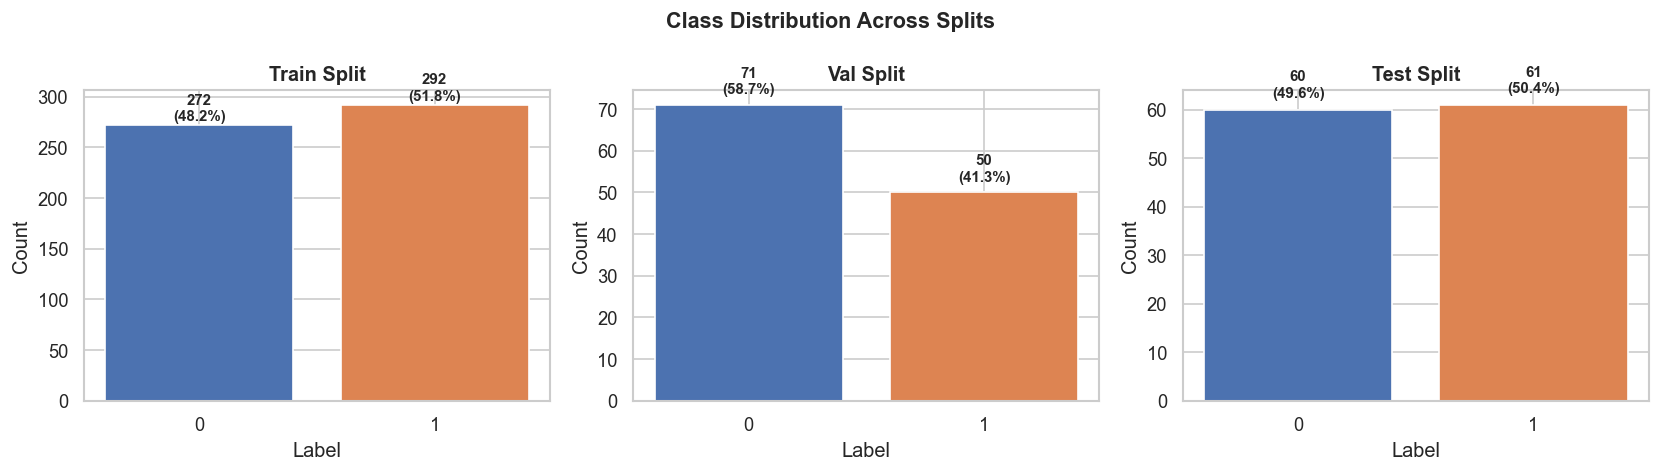

In [4]:
# Class distribution across all three splits
splits = {'Train': train_df, 'Val': val_df, 'Test': test_df}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#4C72B0', '#DD8452']

for ax, (name, df) in zip(axes, splits.items()):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values, color=colors, edgecolor='white')
    ax.set_title(f'{name} Split', fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        pct = v / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, v + 2,
                f'{v}\n({pct:.1f}%)', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

plt.suptitle('Class Distribution Across Splits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

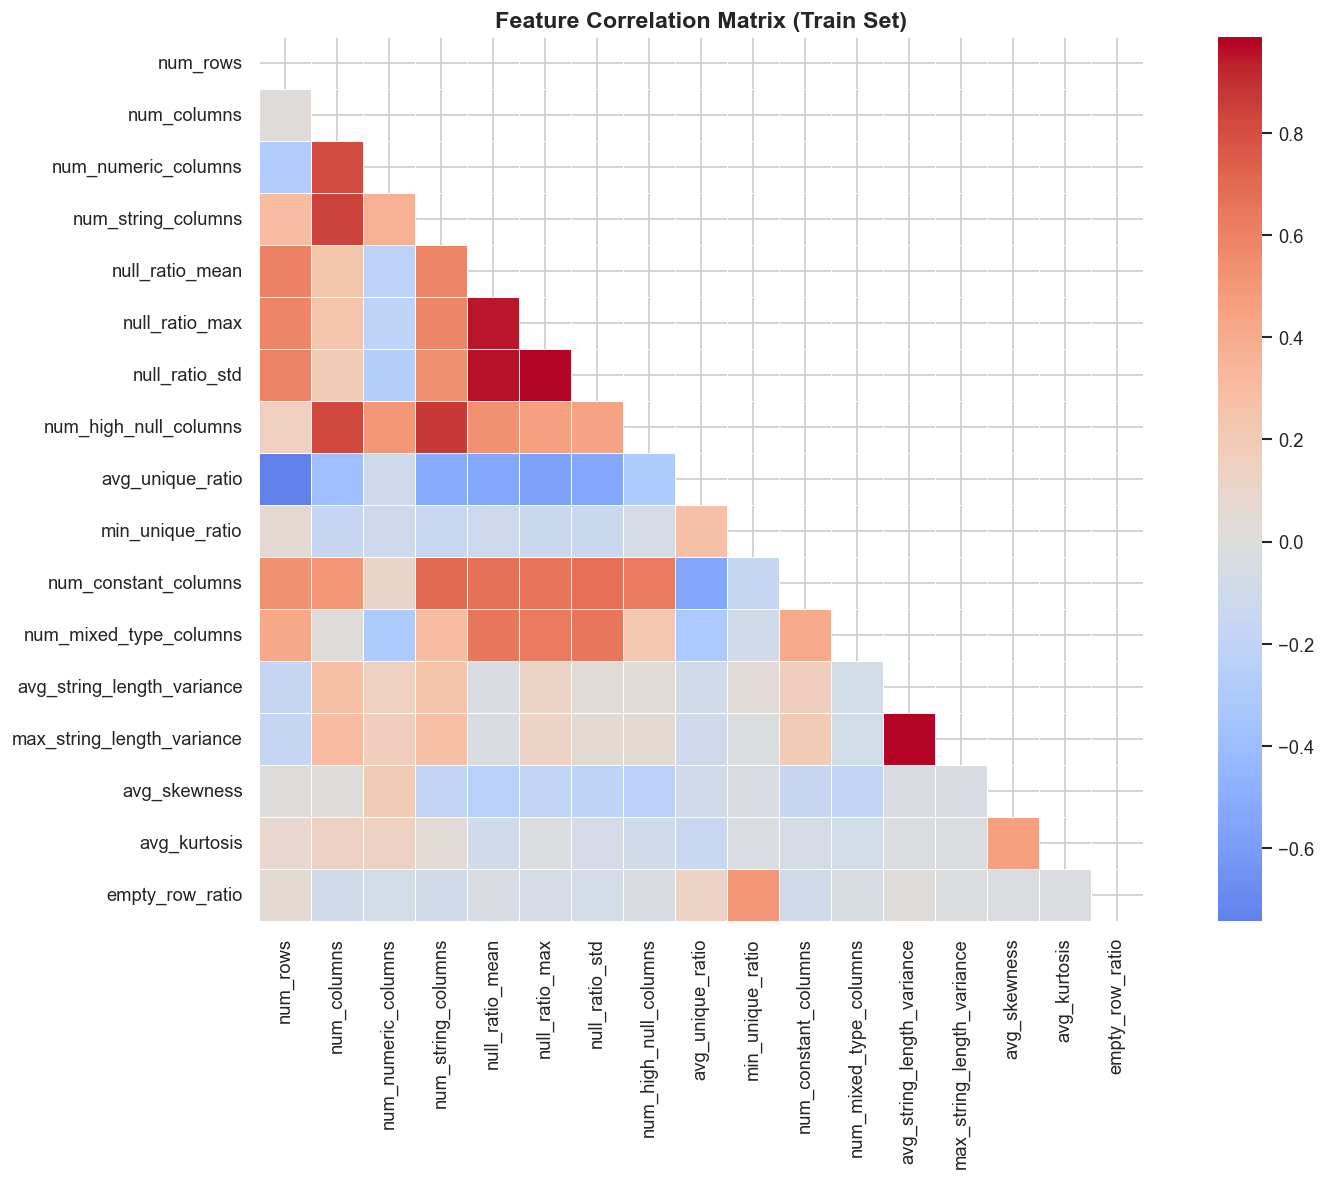

In [5]:
# Feature correlation heatmap — train set only (no leakage)
FEATURE_COLS = [
    'num_rows', 'num_columns', 'num_numeric_columns', 'num_string_columns',
    'null_ratio_mean', 'null_ratio_max', 'null_ratio_std', 'num_high_null_columns',
    'avg_unique_ratio', 'min_unique_ratio',
    'num_constant_columns', 'num_mixed_type_columns',
    'avg_string_length_variance', 'max_string_length_variance',
    'avg_skewness', 'avg_kurtosis', 'empty_row_ratio'
]

corr = train_df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, square=True)
plt.title('Feature Correlation Matrix (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocessing

> Medians are computed **only from the training set** and applied to val/test to prevent leakage.

In [6]:
def prepare_xy(df, train_medians=None):
    """
    Extract features & target.
    Imputes nulls using train_medians (computed from train set only).
    Returns X, y, and the medians used.
    """
    X = df[FEATURE_COLS].copy()
    y = df['label'].copy()
    if train_medians is None:
        train_medians = X.median()
    X = X.fillna(train_medians)
    return X, y, train_medians

X_train, y_train, train_medians = prepare_xy(train_df)
X_val,   y_val,   _             = prepare_xy(val_df,  train_medians)
X_test,  y_test,  _             = prepare_xy(test_df, train_medians)

# Class imbalance ratio (for XGBoost scale_pos_weight — computed from train only)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f'X_train : {X_train.shape}  |  label dist: {dict(y_train.value_counts().sort_index())}')
print(f'X_val   : {X_val.shape}   |  label dist: {dict(y_val.value_counts().sort_index())}')
print(f'X_test  : {X_test.shape}   |  label dist: {dict(y_test.value_counts().sort_index())}')
print(f'\nscale_pos_weight (XGBoost): {scale_pos_weight:.3f}')

X_train : (564, 17)  |  label dist: {0: np.int64(272), 1: np.int64(292)}
X_val   : (121, 17)   |  label dist: {0: np.int64(71), 1: np.int64(50)}
X_test  : (121, 17)   |  label dist: {0: np.int64(60), 1: np.int64(61)}

scale_pos_weight (XGBoost): 0.932


## 5. Define Pipelines

In [7]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print('Pipelines ready ✅')

Pipelines ready ✅


## 6. StratifiedKFold Cross-Validation — Train Set Only

> CV runs exclusively on `train_data.csv`. The val and test sets are **not touched** here.

In [8]:
METRICS = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']

def run_cv(pipeline, X, y, skf, model_name):
    """StratifiedKFold CV — returns per-fold metrics + OOF predictions."""
    fold_metrics = []
    oof_true, oof_pred, oof_prob = [], [], []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
        ytr, yva = y.iloc[tr_idx], y.iloc[va_idx]

        pipeline.fit(Xtr, ytr)
        pred = pipeline.predict(Xva)
        prob = pipeline.predict_proba(Xva)[:, 1]

        fold_metrics.append({
            'fold':      fold,
            'accuracy':  accuracy_score(yva, pred),
            'f1':        f1_score(yva, pred, zero_division=0),
            'precision': precision_score(yva, pred, zero_division=0),
            'recall':    recall_score(yva, pred, zero_division=0),
            'roc_auc':   roc_auc_score(yva, prob),
        })

        oof_true.extend(yva.tolist())
        oof_pred.extend(pred.tolist())
        oof_prob.extend(prob.tolist())

        print(f'  [{model_name}] Fold {fold}  '
              f'Acc={fold_metrics[-1]["accuracy"]:.4f}  '
              f'F1={fold_metrics[-1]["f1"]:.4f}  '
              f'AUC={fold_metrics[-1]["roc_auc"]:.4f}')

    return (pd.DataFrame(fold_metrics),
            np.array(oof_true), np.array(oof_pred), np.array(oof_prob))


skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print('=== Random Forest — StratifiedKFold (train set) ===')
rf_folds, rf_oof_true, rf_oof_pred, rf_oof_prob = run_cv(
    rf_pipeline, X_train, y_train, skf, 'RF'
)

print('\n=== XGBoost — StratifiedKFold (train set) ===')
xgb_folds, xgb_oof_true, xgb_oof_pred, xgb_oof_prob = run_cv(
    xgb_pipeline, X_train, y_train, skf, 'XGB'
)

=== Random Forest — StratifiedKFold (train set) ===
  [RF] Fold 1  Acc=0.9204  F1=0.9268  AUC=0.9387
  [RF] Fold 2  Acc=0.9381  F1=0.9402  AUC=0.9893
  [RF] Fold 3  Acc=0.9115  F1=0.9138  AUC=0.9711
  [RF] Fold 4  Acc=0.9381  F1=0.9402  AUC=0.9761
  [RF] Fold 5  Acc=0.9643  F1=0.9655  AUC=0.9917

=== XGBoost — StratifiedKFold (train set) ===
  [XGB] Fold 1  Acc=0.9292  F1=0.9355  AUC=0.9453
  [XGB] Fold 2  Acc=0.9469  F1=0.9492  AUC=0.9868
  [XGB] Fold 3  Acc=0.9381  F1=0.9412  AUC=0.9639
  [XGB] Fold 4  Acc=0.9381  F1=0.9402  AUC=0.9793
  [XGB] Fold 5  Acc=0.9554  F1=0.9573  AUC=0.9933


## 7. CV Summary Statistics

In [9]:
rows = []
for name, folds in [('Random Forest', rf_folds), ('XGBoost', xgb_folds)]:
    r = {'Model': name}
    for m in METRICS:
        r[m.upper()] = f"{folds[m].mean():.4f} ± {folds[m].std():.4f}"
    rows.append(r)

pd.set_option('display.max_colwidth', None)
print('=== CV Summary (mean ± std across folds) ===')
pd.DataFrame(rows).set_index('Model')

=== CV Summary (mean ± std across folds) ===


,ACCURACY,F1,PRECISION,RECALL,ROC_AUC
Model,,,,,
Random Forest,0.9345 ± 0.0203,0.9373 ± 0.0192,0.9305 ± 0.0332,0.9454 ± 0.0324,0.9734 ± 0.0212
XGBoost,0.9415 ± 0.0100,0.9446 ± 0.0086,0.9286 ± 0.0289,0.9625 ± 0.0251,0.9737 ± 0.0193


## 8. CV Visualizations

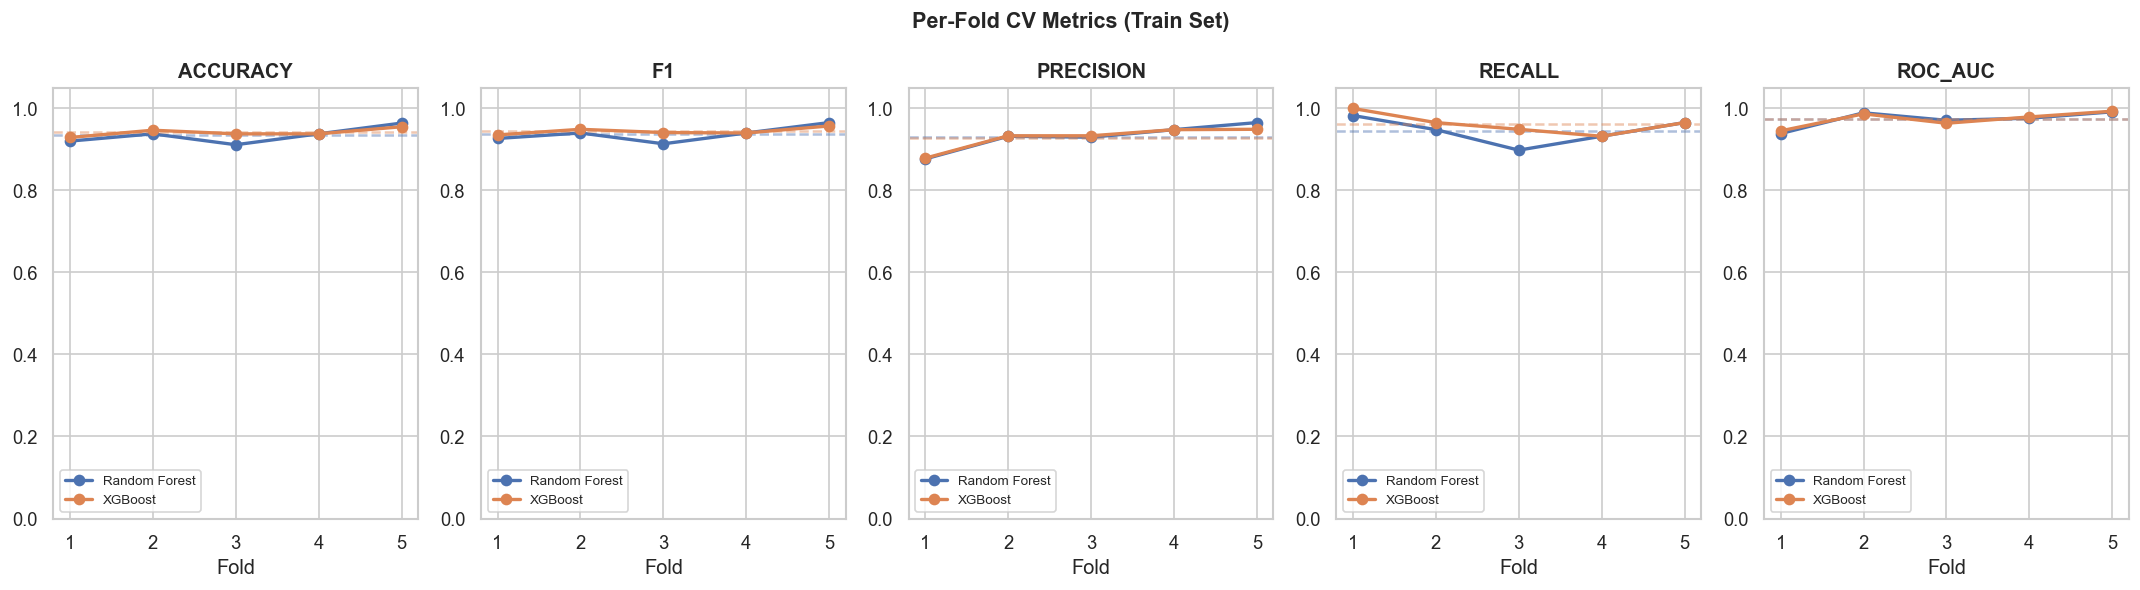

In [10]:
rf_folds['Model']  = 'Random Forest'
xgb_folds['Model'] = 'XGBoost'
combined = pd.concat([rf_folds, xgb_folds], ignore_index=True)
model_colors = {'Random Forest': '#4C72B0', 'XGBoost': '#DD8452'}

# Line plots — per fold
fig, axes = plt.subplots(1, len(METRICS), figsize=(18, 5))
for ax, metric in zip(axes, METRICS):
    for model, grp in combined.groupby('Model'):
        ax.plot(grp['fold'], grp[metric], marker='o', label=model,
                color=model_colors[model], linewidth=2)
        ax.axhline(grp[metric].mean(), linestyle='--',
                   color=model_colors[model], alpha=0.45)
    ax.set_title(metric.upper(), fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_xticks(range(1, N_SPLITS + 1))
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
plt.suptitle('Per-Fold CV Metrics (Train Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

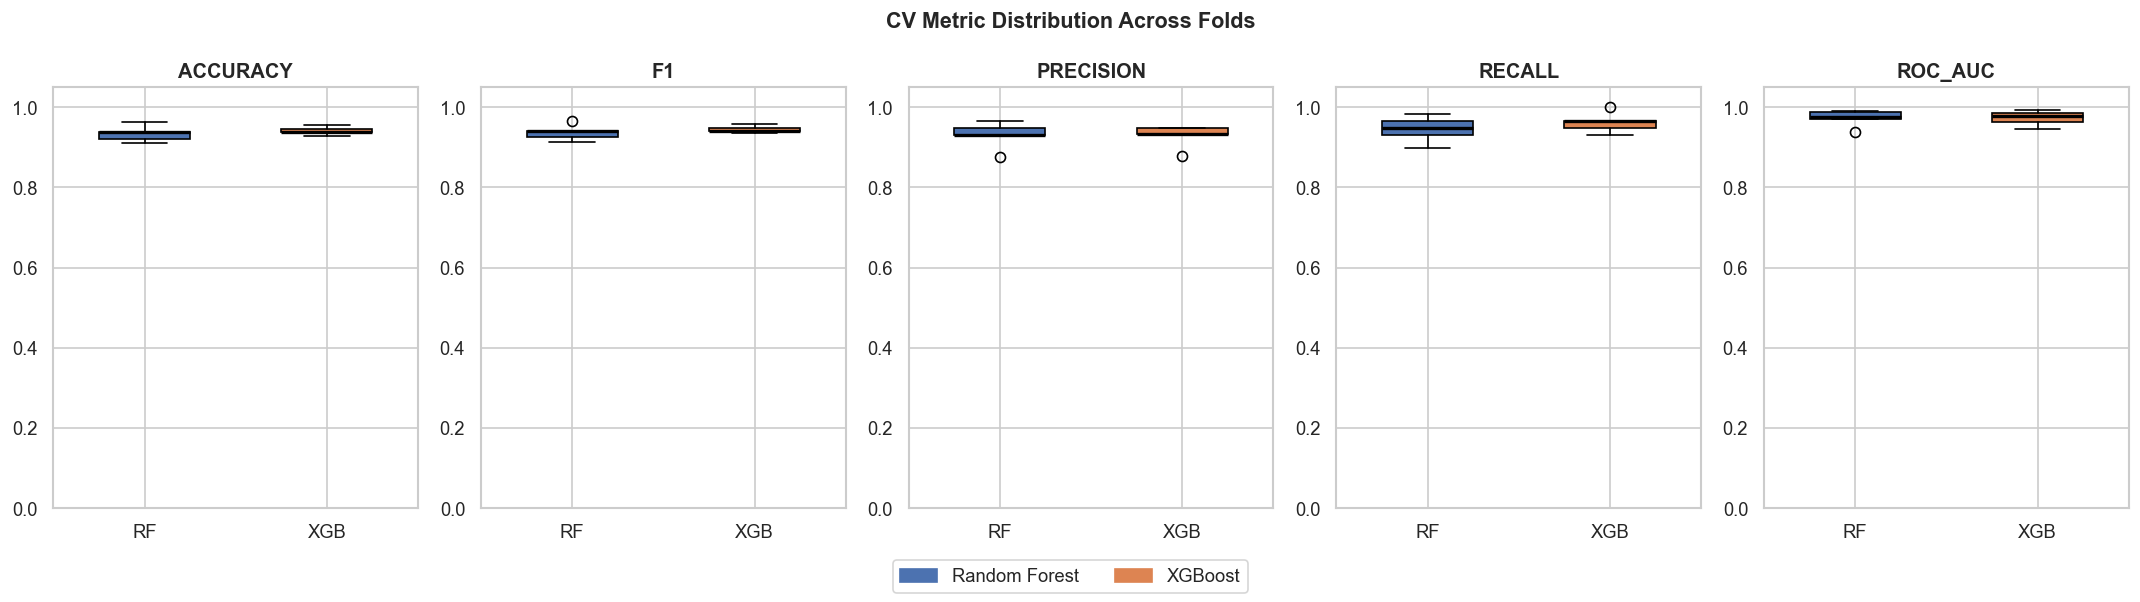

In [11]:
# Box plots — spread across folds
fig, axes = plt.subplots(1, len(METRICS), figsize=(18, 5))
for ax, metric in zip(axes, METRICS):
    data = [rf_folds[metric].values, xgb_folds[metric].values]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][1].set_facecolor('#DD8452')
    ax.set_xticklabels(['RF', 'XGB'])
    ax.set_title(metric.upper(), fontweight='bold')
    ax.set_ylim(0, 1.05)
rf_patch  = mpatches.Patch(color='#4C72B0', label='Random Forest')
xgb_patch = mpatches.Patch(color='#DD8452', label='XGBoost')
fig.legend(handles=[rf_patch, xgb_patch], loc='lower center', ncol=2, fontsize=11)
plt.suptitle('CV Metric Distribution Across Folds', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

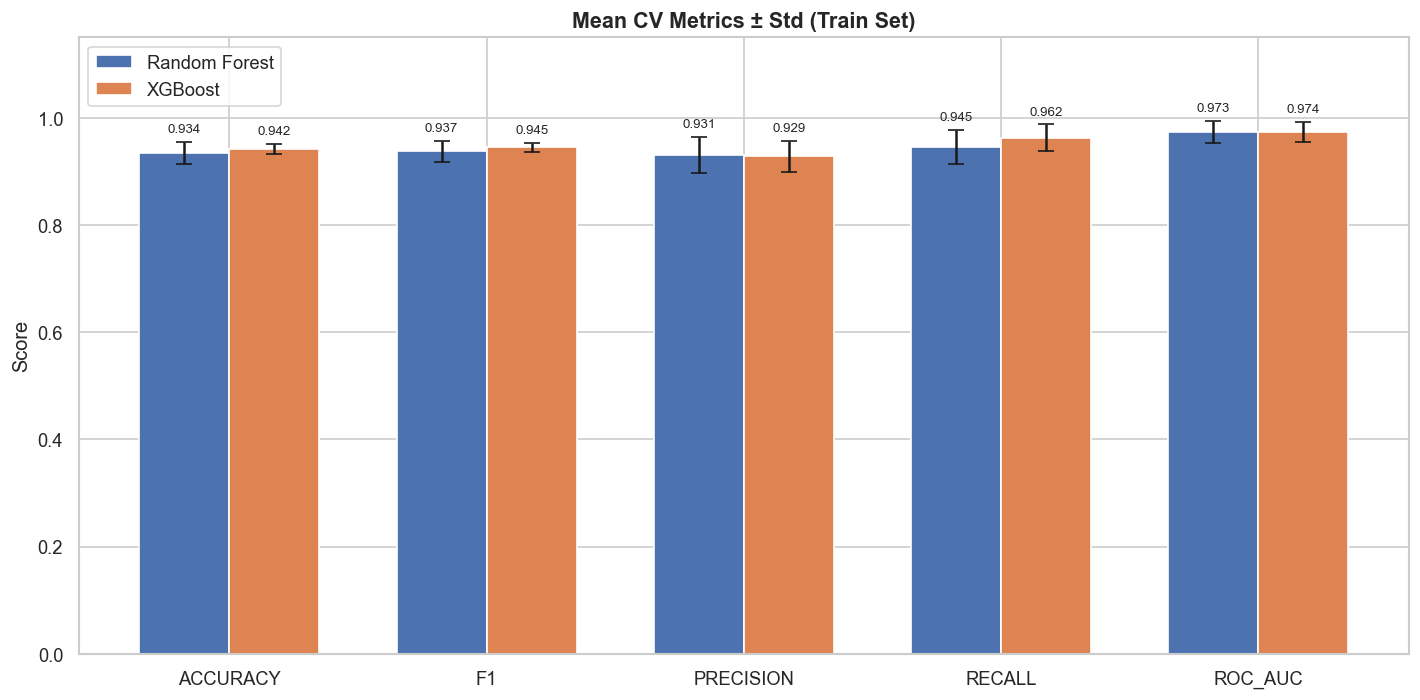

In [12]:
# Grouped bar — mean CV metrics ± std
rf_means  = [rf_folds[m].mean()  for m in METRICS]
xgb_means = [xgb_folds[m].mean() for m in METRICS]
rf_stds   = [rf_folds[m].std()   for m in METRICS]
xgb_stds  = [xgb_folds[m].std()  for m in METRICS]

x = np.arange(len(METRICS))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w/2, rf_means,  w, yerr=rf_stds,  label='Random Forest',
            color='#4C72B0', capsize=5, edgecolor='white')
b2 = ax.bar(x + w/2, xgb_means, w, yerr=xgb_stds, label='XGBoost',
            color='#DD8452', capsize=5, edgecolor='white')
ax.bar_label(b1, fmt='%.3f', padding=4, fontsize=8)
ax.bar_label(b2, fmt='%.3f', padding=4, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in METRICS], fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.set_title('Mean CV Metrics ± Std (Train Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Retrain on Full Training Set → Evaluate on Validation Set

> Each pipeline is now retrained on **all** of `train_data.csv` and scored on `val_data.csv`.

In [13]:
METRIC_LABELS = ['Accuracy', 'F1', 'Precision', 'Recall', 'ROC-AUC']

def evaluate_split(pipeline, X_fit, y_fit, X_eval, y_eval, model_name, split_name):
    """Fit on X_fit/y_fit, predict on X_eval/y_eval, return metrics + predictions."""
    pipeline.fit(X_fit, y_fit)
    pred = pipeline.predict(X_eval)
    prob = pipeline.predict_proba(X_eval)[:, 1]
    metrics = {
        'Model':     model_name,
        'Split':     split_name,
        'Accuracy':  accuracy_score(y_eval, pred),
        'F1':        f1_score(y_eval, pred, zero_division=0),
        'Precision': precision_score(y_eval, pred, zero_division=0),
        'Recall':    recall_score(y_eval, pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_eval, prob),
    }
    return metrics, pred, prob

rf_val_metrics,  rf_val_pred,  rf_val_prob  = evaluate_split(
    rf_pipeline,  X_train, y_train, X_val, y_val, 'Random Forest', 'Validation')
xgb_val_metrics, xgb_val_pred, xgb_val_prob = evaluate_split(
    xgb_pipeline, X_train, y_train, X_val, y_val, 'XGBoost', 'Validation')

val_df_out = pd.DataFrame([rf_val_metrics, xgb_val_metrics]).set_index('Model').drop(columns='Split')
print('=== Validation Set Results ===')
val_df_out.round(4)

=== Validation Set Results ===


,Accuracy,F1,Precision,Recall,ROC-AUC
Model,,,,,
Random Forest,0.9256,0.9159,0.8596,0.98,0.9744
XGBoost,0.9421,0.9346,0.8772,1.00,0.9713


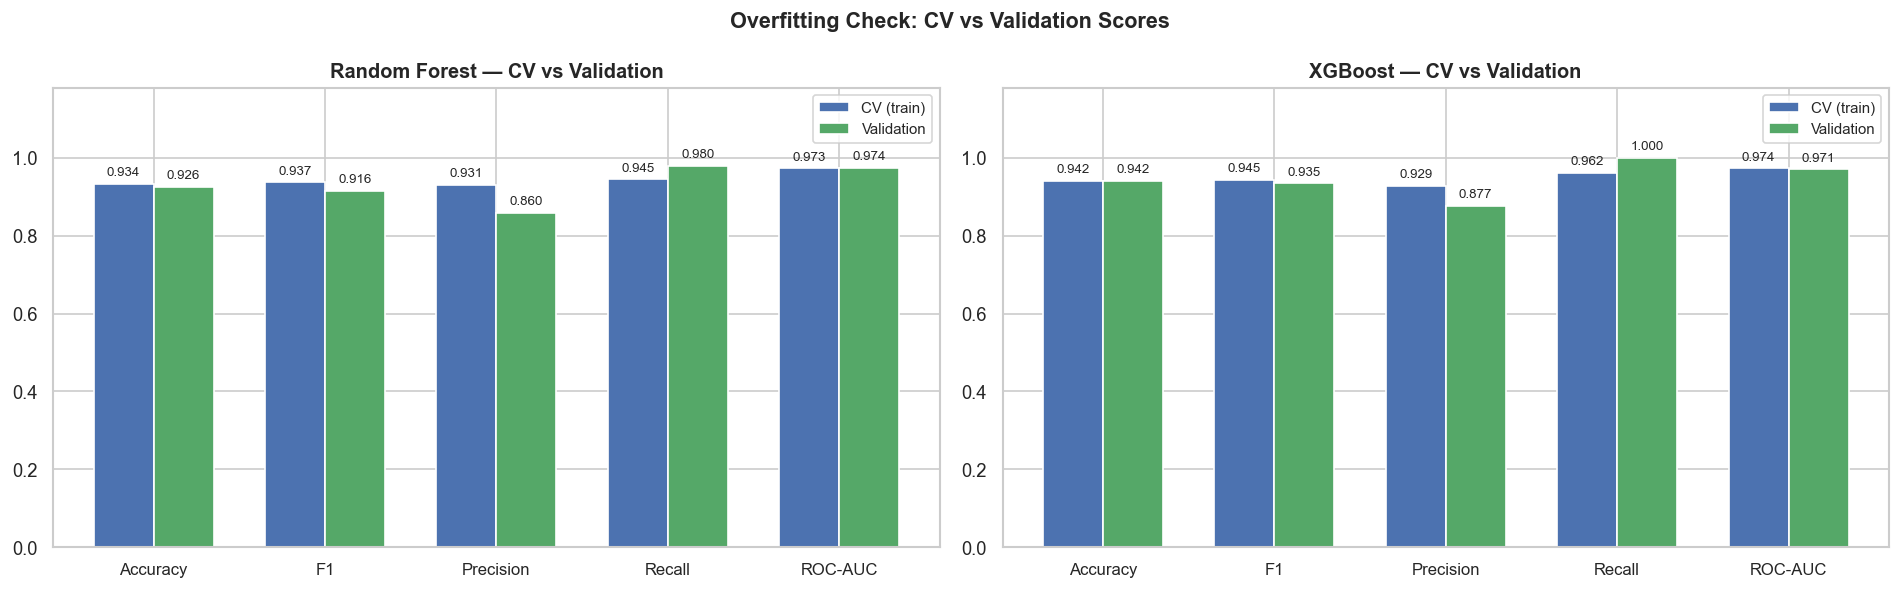

In [14]:
# CV vs Val comparison bars (overfitting check)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (model_name, cv_folds, val_m) in zip(axes, [
    ('Random Forest', rf_folds,  rf_val_metrics),
    ('XGBoost',       xgb_folds, xgb_val_metrics),
]):
    cv_means = [cv_folds[m].mean() for m in METRICS]
    val_vals = [val_m[k] for k in METRIC_LABELS]
    x = np.arange(len(METRICS))
    w = 0.35
    b1 = ax.bar(x - w/2, cv_means, w, label='CV (train)', color='#4C72B0', edgecolor='white')
    b2 = ax.bar(x + w/2, val_vals, w, label='Validation', color='#55A868', edgecolor='white')
    ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=8)
    ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(METRIC_LABELS, fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.set_title(f'{model_name} — CV vs Validation', fontweight='bold')
    ax.legend(fontsize=9)
plt.suptitle('Overfitting Check: CV vs Validation Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

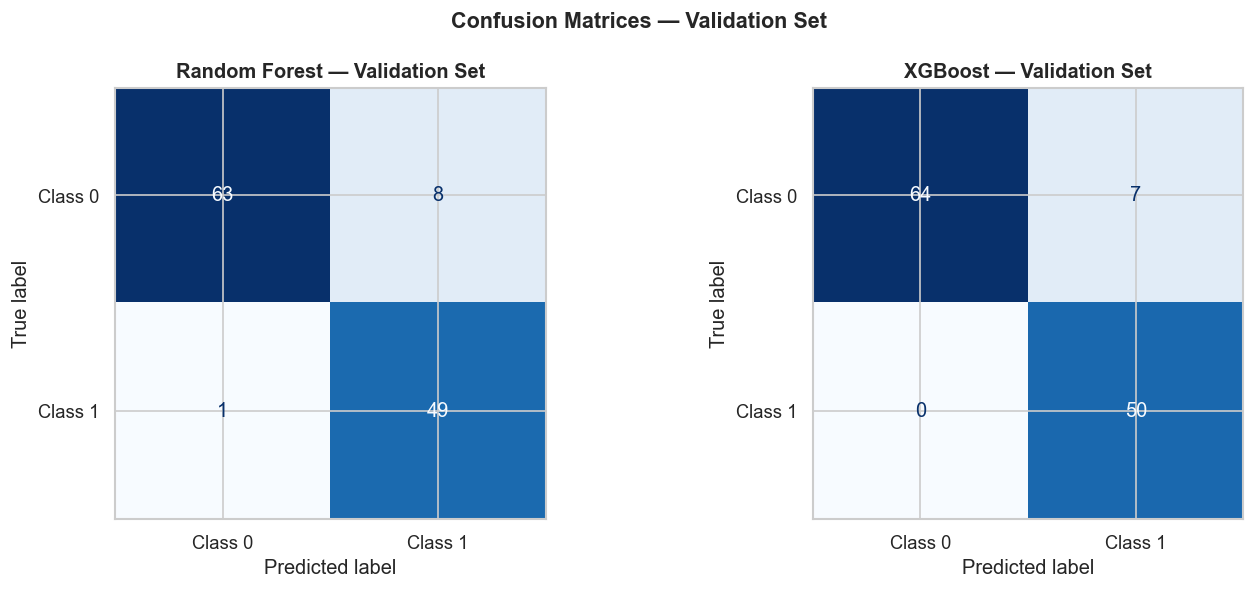

In [15]:
# Confusion matrices — Validation set
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, [
    ('Random Forest', rf_val_pred),
    ('XGBoost',       xgb_val_pred),
]):
    cm = confusion_matrix(y_val, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Class 0', 'Class 1']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} — Validation Set', fontweight='bold')
plt.suptitle('Confusion Matrices — Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

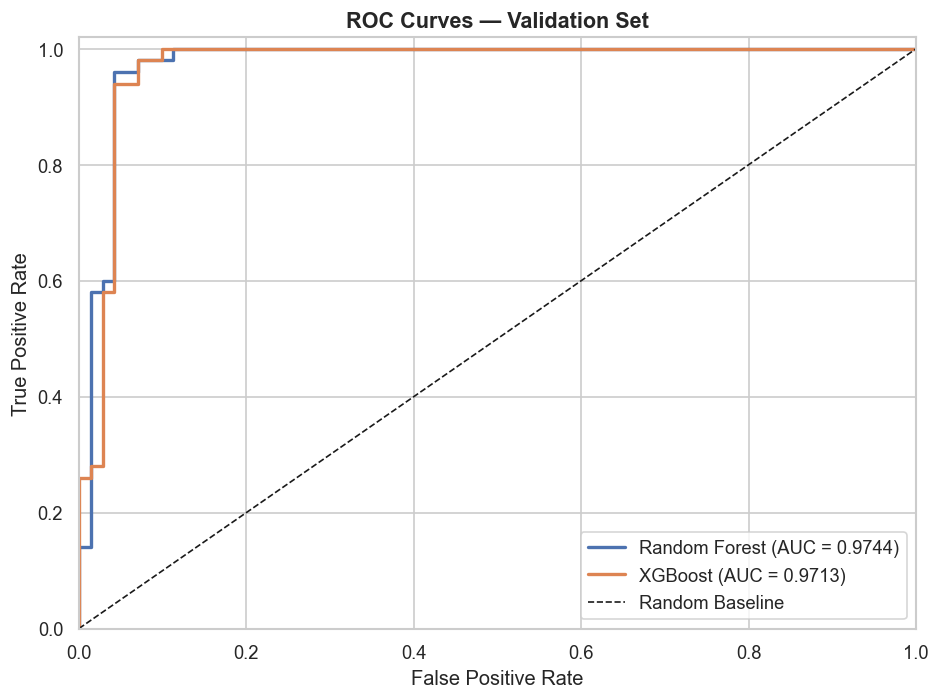

In [16]:
# ROC curves — Validation set
fig, ax = plt.subplots(figsize=(8, 6))
for y_prob, label, color in [
    (rf_val_prob,  'Random Forest', '#4C72B0'),
    (xgb_val_prob, 'XGBoost',       '#DD8452'),
]:
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{label} (AUC = {auc(fpr, tpr):.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Validation Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

In [17]:
print('=== Random Forest — Validation Set ===')
print(classification_report(y_val, rf_val_pred, target_names=['Class 0', 'Class 1']))

print('\n=== XGBoost — Validation Set ===')
print(classification_report(y_val, xgb_val_pred, target_names=['Class 0', 'Class 1']))

=== Random Forest — Validation Set ===
              precision    recall  f1-score   support

     Class 0       0.98      0.89      0.93        71
     Class 1       0.86      0.98      0.92        50

    accuracy                           0.93       121
   macro avg       0.92      0.93      0.92       121
weighted avg       0.93      0.93      0.93       121


=== XGBoost — Validation Set ===
              precision    recall  f1-score   support

     Class 0       1.00      0.90      0.95        71
     Class 1       0.88      1.00      0.93        50

    accuracy                           0.94       121
   macro avg       0.94      0.95      0.94       121
weighted avg       0.95      0.94      0.94       121



## 10. Feature Importance

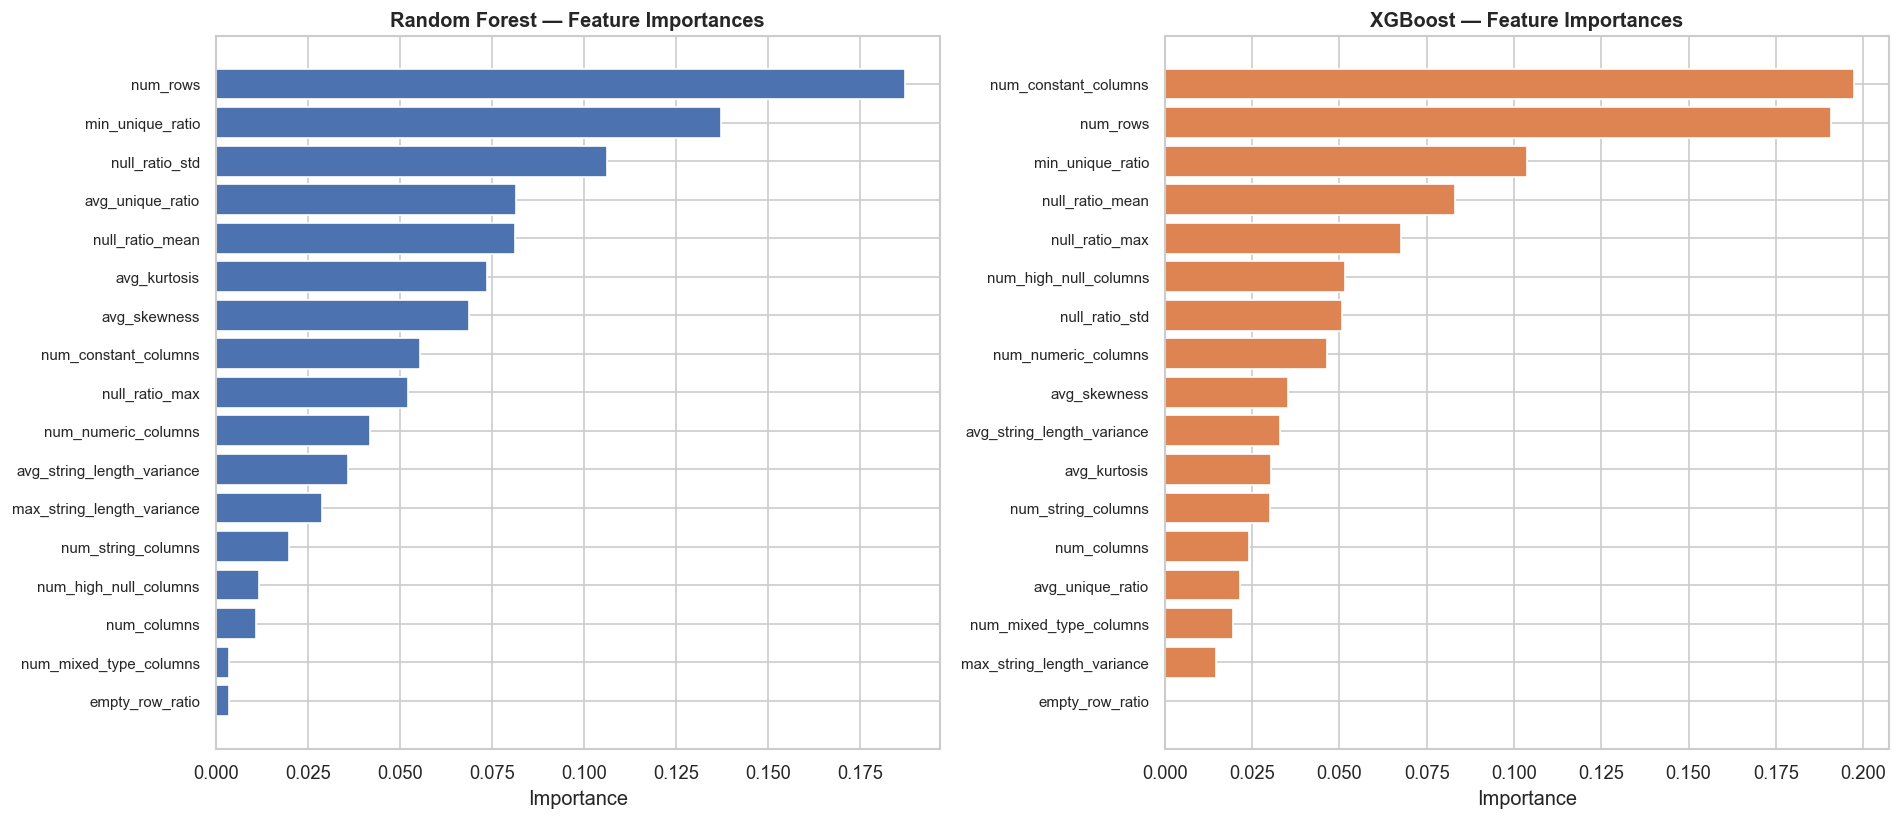

In [18]:
# Models are already fit on full train set from Section 9
imp_df = pd.DataFrame({
    'Feature':       FEATURE_COLS,
    'Random Forest': rf_pipeline.named_steps['clf'].feature_importances_,
    'XGBoost':       xgb_pipeline.named_steps['clf'].feature_importances_,
})
imp_df['avg'] = (imp_df['Random Forest'] + imp_df['XGBoost']) / 2

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, col, color, title in [
    (axes[0], 'Random Forest', '#4C72B0', 'Random Forest'),
    (axes[1], 'XGBoost',       '#DD8452', 'XGBoost'),
]:
    df_s = imp_df.sort_values(col, ascending=True)
    ax.barh(df_s['Feature'], df_s[col], color=color, edgecolor='white')
    ax.set_title(f'{title} — Feature Importances', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

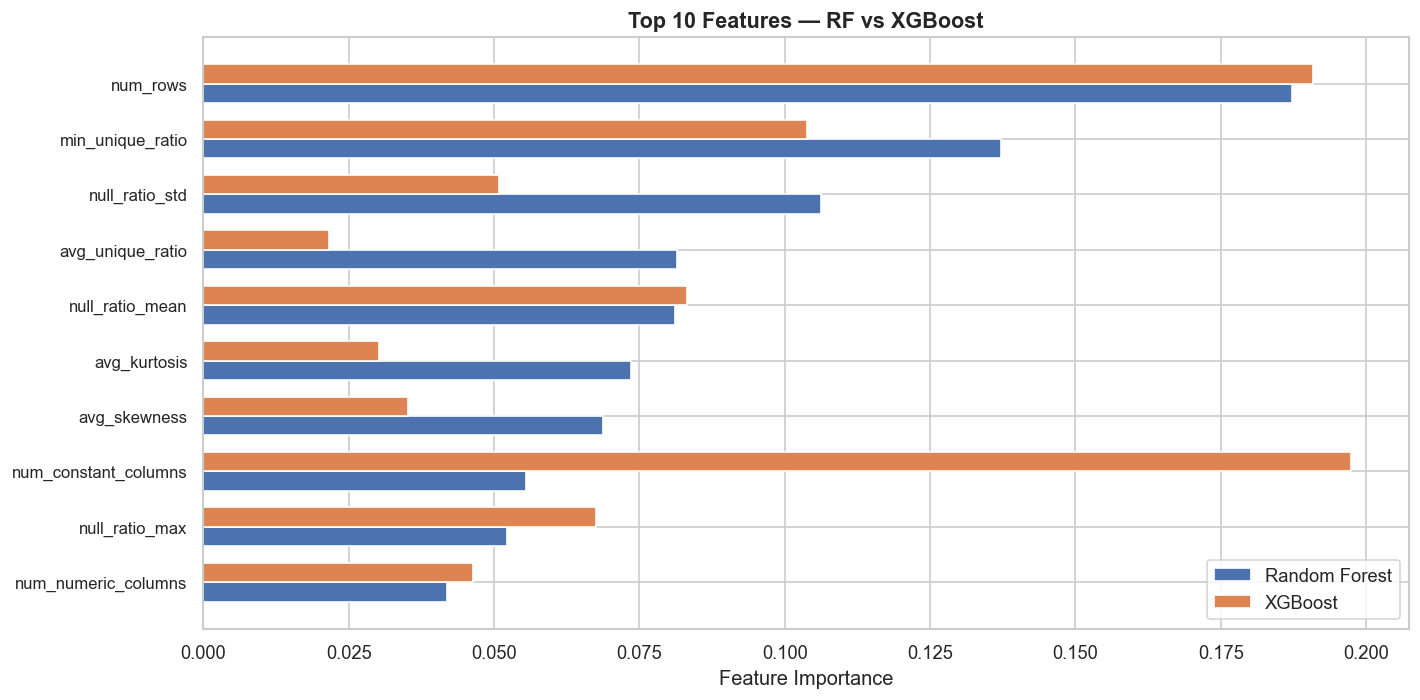

In [19]:
# Top 10 side-by-side
top10 = imp_df.nlargest(10, 'avg').sort_values('Random Forest', ascending=True)
x = np.arange(len(top10))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(x - w/2, top10['Random Forest'], w, label='Random Forest',
        color='#4C72B0', edgecolor='white')
ax.barh(x + w/2, top10['XGBoost'],       w, label='XGBoost',
        color='#DD8452', edgecolor='white')
ax.set_yticks(x)
ax.set_yticklabels(top10['Feature'], fontsize=10)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 10 Features — RF vs XGBoost', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 11. 🏁 Final Evaluation — Test Set

> **Touched only once.** No changes to models after this point.

In [20]:
rf_test_metrics,  rf_test_pred,  rf_test_prob  = evaluate_split(
    rf_pipeline,  X_train, y_train, X_test, y_test, 'Random Forest', 'Test')
xgb_test_metrics, xgb_test_pred, xgb_test_prob = evaluate_split(
    xgb_pipeline, X_train, y_train, X_test, y_test, 'XGBoost', 'Test')

test_df_out = pd.DataFrame([rf_test_metrics, xgb_test_metrics]).set_index('Model').drop(columns='Split')
print('=== TEST SET Results ===')
test_df_out.round(4)

=== TEST SET Results ===


,Accuracy,F1,Precision,Recall,ROC-AUC
Model,,,,,
Random Forest,0.9421,0.944,0.9219,0.9672,0.9697
XGBoost,0.9256,0.928,0.9062,0.9508,0.9740


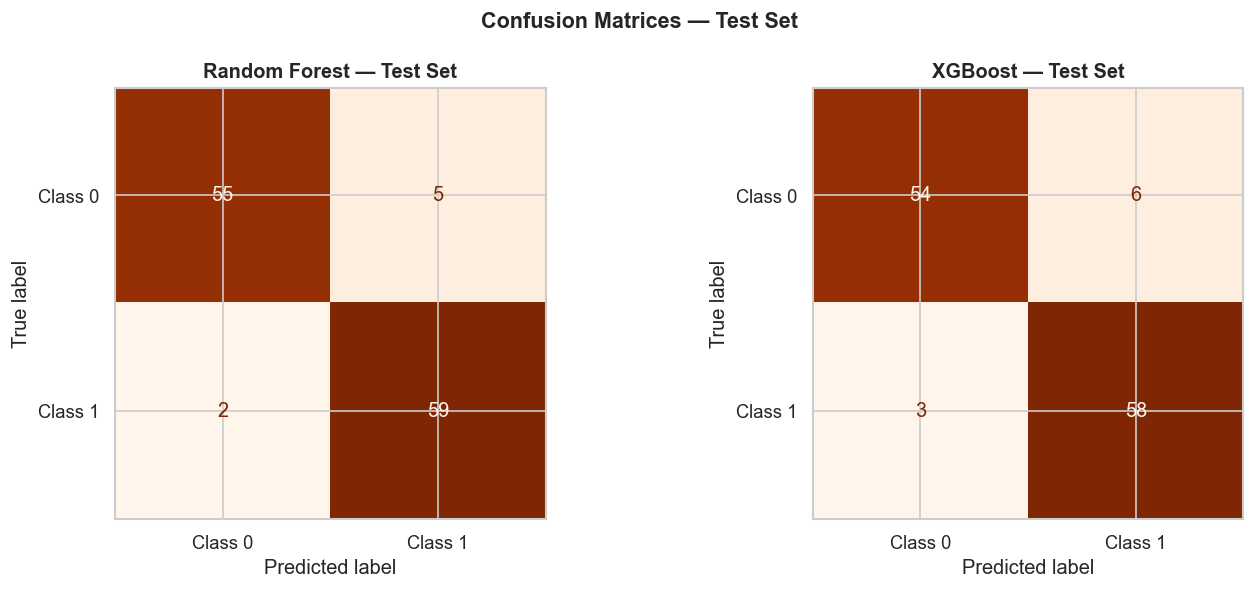

In [21]:
# Confusion matrices — Test set
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, [
    ('Random Forest', rf_test_pred),
    ('XGBoost',       xgb_test_pred),
]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Class 0', 'Class 1']).plot(
        ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(f'{name} — Test Set', fontweight='bold')
plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

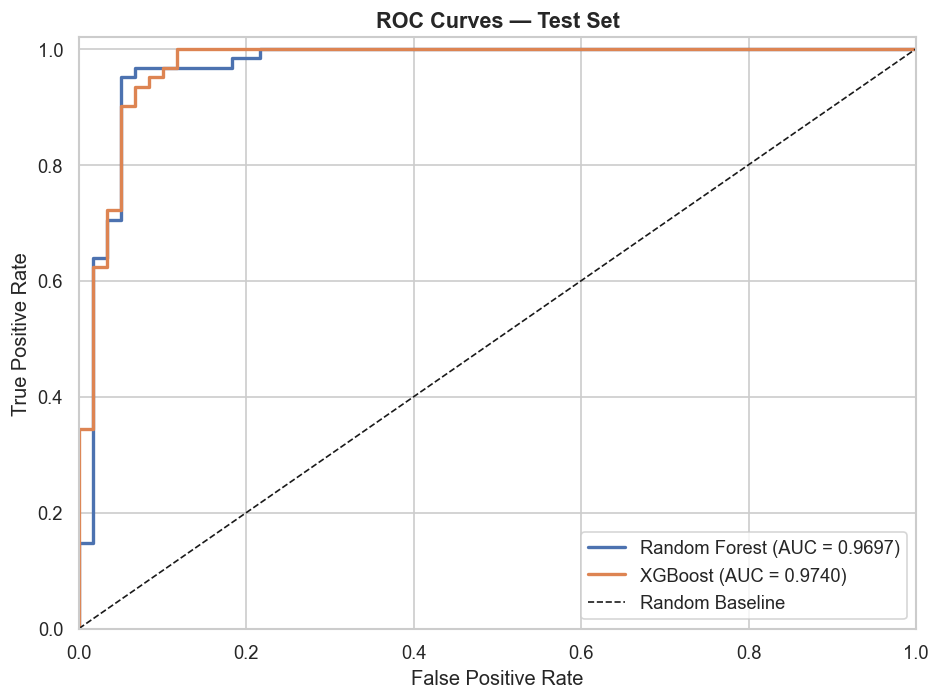

In [22]:
# ROC curves — Test set
fig, ax = plt.subplots(figsize=(8, 6))
for y_prob, label, color in [
    (rf_test_prob,  'Random Forest', '#4C72B0'),
    (xgb_test_prob, 'XGBoost',       '#DD8452'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{label} (AUC = {auc(fpr, tpr):.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

In [23]:
print('=== Random Forest — Test Set ===')
print(classification_report(y_test, rf_test_pred, target_names=['Class 0', 'Class 1']))

print('\n=== XGBoost — Test Set ===')
print(classification_report(y_test, xgb_test_pred, target_names=['Class 0', 'Class 1']))

=== Random Forest — Test Set ===
              precision    recall  f1-score   support

     Class 0       0.96      0.92      0.94        60
     Class 1       0.92      0.97      0.94        61

    accuracy                           0.94       121
   macro avg       0.94      0.94      0.94       121
weighted avg       0.94      0.94      0.94       121


=== XGBoost — Test Set ===
              precision    recall  f1-score   support

     Class 0       0.95      0.90      0.92        60
     Class 1       0.91      0.95      0.93        61

    accuracy                           0.93       121
   macro avg       0.93      0.93      0.93       121
weighted avg       0.93      0.93      0.93       121



## 12. Full Summary — CV / Val / Test

In [24]:
score_rows = []
for model_name, cv_folds, val_m, test_m in [
    ('Random Forest', rf_folds,  rf_val_metrics,  rf_test_metrics),
    ('XGBoost',       xgb_folds, xgb_val_metrics, xgb_test_metrics),
]:
    for stage, src in [('CV (train)', None), ('Validation', val_m), ('Test', test_m)]:
        r = {'Model': model_name, 'Stage': stage}
        if src is None:
            for m, k in zip(METRICS, METRIC_LABELS):
                r[k] = cv_folds[m].mean()
        else:
            for k in METRIC_LABELS:
                r[k] = src[k]
        score_rows.append(r)

full_summary = pd.DataFrame(score_rows).set_index(['Model', 'Stage'])
print('=== Complete Score Summary ===')
full_summary.round(4)

=== Complete Score Summary ===


Accuracy      F1  Precision  Recall  ROC-AUC
Model         Stage                                                   
Random Forest CV (train)    0.9345  0.9373     0.9305  0.9454   0.9734
              Validation    0.9256  0.9159     0.8596  0.9800   0.9744
              Test          0.9421  0.9440     0.9219  0.9672   0.9697
XGBoost       CV (train)    0.9415  0.9446     0.9286  0.9625   0.9737
              Validation    0.9421  0.9346     0.8772  1.0000   0.9713
              Test          0.9256  0.9280     0.9062  0.9508   0.9740

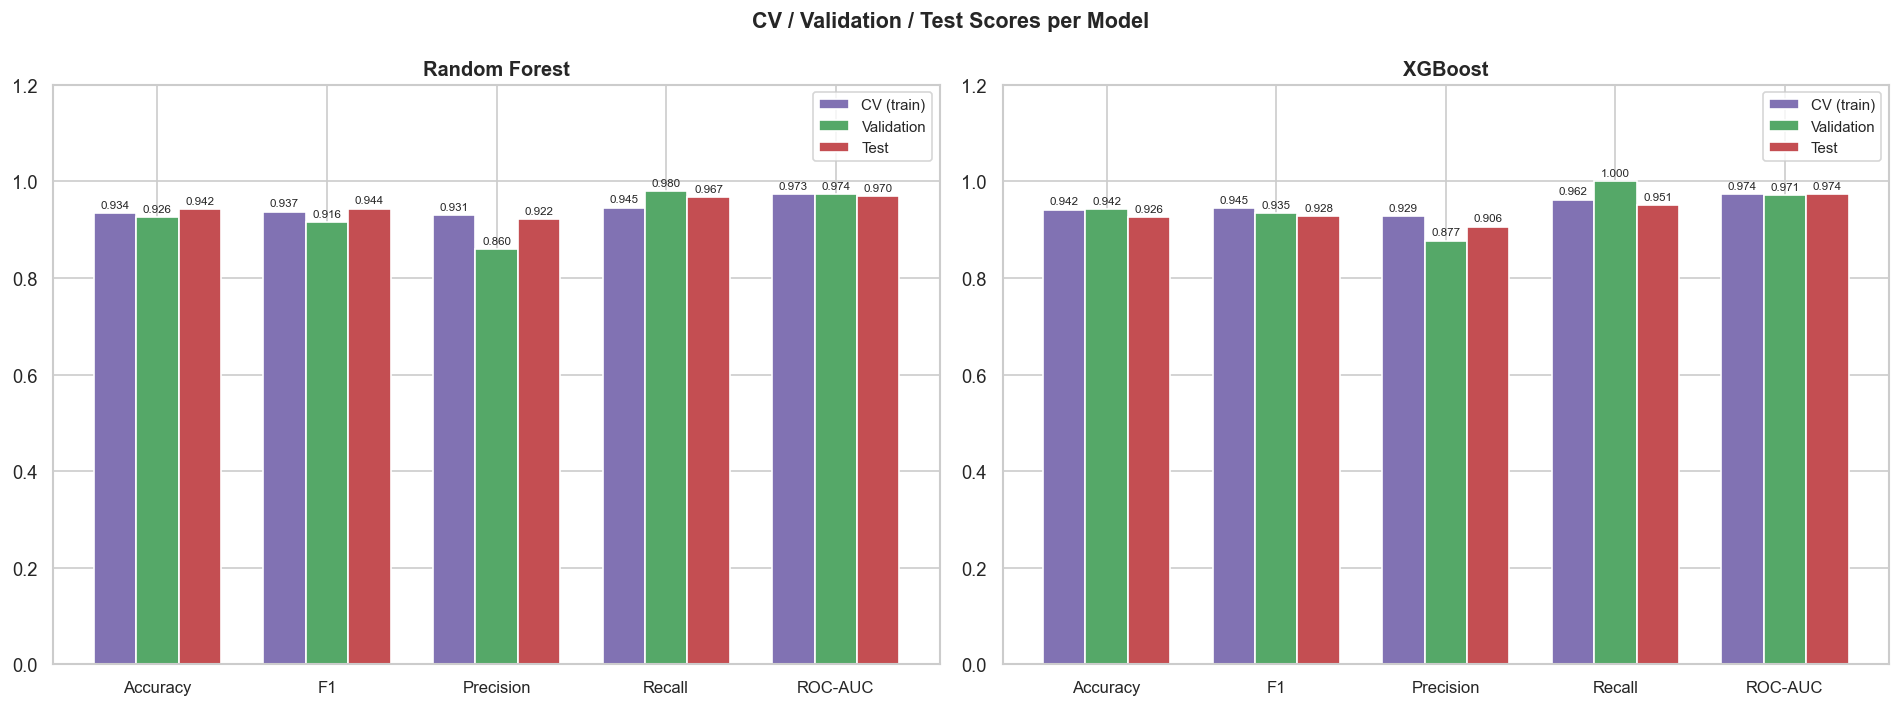

In [25]:
# CV / Val / Test grouped bars per model
stages = ['CV (train)', 'Validation', 'Test']
stage_colors = {'CV (train)': '#8172B3', 'Validation': '#55A868', 'Test': '#C44E52'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    x = np.arange(len(METRIC_LABELS))
    width = 0.25
    for i, stage in enumerate(stages):
        vals = full_summary.loc[(model_name, stage)].values.astype(float)
        bars = ax.bar(x + (i - 1) * width, vals, width,
                      label=stage, color=stage_colors[stage], edgecolor='white')
        ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(METRIC_LABELS, fontsize=10)
    ax.set_ylim(0, 1.2)
    ax.set_title(model_name, fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
plt.suptitle('CV / Validation / Test Scores per Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Final Verdict

In [26]:
print('=' * 68)
print('           FINAL MODEL COMPARISON — TEST SET')
print('=' * 68)
print(f"{'Metric':<14} {'Random Forest':>18} {'XGBoost':>18} {'Winner':>12}")
print('-' * 68)
for k in METRIC_LABELS:
    rf_v  = rf_test_metrics[k]
    xgb_v = xgb_test_metrics[k]
    winner = 'RF ✅' if rf_v >= xgb_v else 'XGB ✅'
    print(f"{k:<14} {rf_v:>18.4f} {xgb_v:>18.4f} {winner:>12}")
print('=' * 68)

           FINAL MODEL COMPARISON — TEST SET
Metric              Random Forest            XGBoost       Winner
--------------------------------------------------------------------
Accuracy                   0.9421             0.9256         RF ✅
F1                         0.9440             0.9280         RF ✅
Precision                  0.9219             0.9062         RF ✅
Recall                     0.9672             0.9508         RF ✅
ROC-AUC                    0.9697             0.9740        XGB ✅
